In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Task 1 — Data Loading & Exploration
Load the CSV file using Pandas

In [59]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/WA_Fn-UseC_-HR-Employee-Attrition.csv")
# Keep original dataset for EDA
eda_df = df.copy()

Display the first 10 rows

In [60]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Check how many rows and columns are there

In [61]:
print("Size of Dataset:", df.shape)
print("Rows:", df.shape[0])   #first 0 index tells about total rows
print("Columns:", df.shape[1])  #and the second 1 index tells about total columns

Size of Dataset: (1470, 35)
Rows: 1470
Columns: 35


Identify the target column (Attrition — Yes/No)

In [62]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [63]:
print("Target Column:", "Attrition")

Target Column: Attrition


Count how many employees left vs stayed and calculate the attrition rate as a
percentage

In [64]:
attrition_count = df['Attrition'].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [65]:
attrition_rate = (df['Attrition'].value_counts(normalize=True) * 100) #in percentage

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Identify how many columns are numeric vs categorical

In [66]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", len(numeric_columns))
print("Categorical Columns:", len(categorical_columns))

Numeric Columns: 26
Categorical Columns: 9


Write one observation: what do you notice about the attrition rate — is it balanced or
imbalanced?

In [67]:
#Observation
# The dataset contains approximately 84% employees who stayed and 16% employees who left the company. This indicates that the dataset is Imbalanced.because of this imbalance, relying only on accuracy may be misleading. Therefore, additional evaluation metrics such as precision, recall, f1-score, and roc-auc will be used in later tasks to assess model performance.

##Task 2 — Data Cleaning & Preprocessing
Check for missing/null values and handle them

In [68]:
# Check missing values

missing_values = df.isnull().sum()
print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [69]:
print("total missing values are:", df.isnull().sum().sum())

total missing values are: 0


Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18,
StandardHours — these are constant or irrelevant)

In [70]:
df.drop(
    columns=[
        'EmployeeCount',
        'EmployeeNumber',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)
print("Remaining Columns:", df.shape[1]) # we drop these columns because they don't help in prediction

Remaining Columns: 31


Convert the target column Attrition from Yes/No to 1/0

In [71]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


Encode all remaining categorical columns using One-Hot Encoding (e.g.,
Department, JobRole, MaritalStatus, BusinessTravel)

In [72]:
categorical_columns = df.select_dtypes(include='object').columns
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [73]:
df = pd.get_dummies(df,columns=categorical_columns,drop_first=True)
print(df.shape)

(1470, 45)


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   HourlyRate                         1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MonthlyIncome                      1470 non-null   int64
 11  MonthlyRate                        1470 non-null   int64
 12  NumCompaniesWorked  

In [75]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape) #separate features and target variable

Features Shape: (1470, 44)
Target Shape: (1470,)


Scale numeric features using StandardScaler

In [76]:
from sklearn.preprocessing import StandardScaler
numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns # help in finding numeric columns only

X_scaled = X.copy() # Create a copy of X

scaler = StandardScaler() # Scale only numeric columns

X_scaled[numeric_columns] = scaler.fit_transform(X_scaled[numeric_columns])

In [77]:
print("Feature Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

X_scaled.head()

Feature Shape: (1470, 44)
Target Shape: (1470,)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


##Task 3 — Exploratory Data Analysis — EDA
1.Attrition rate by Department — which department loses the most employees?

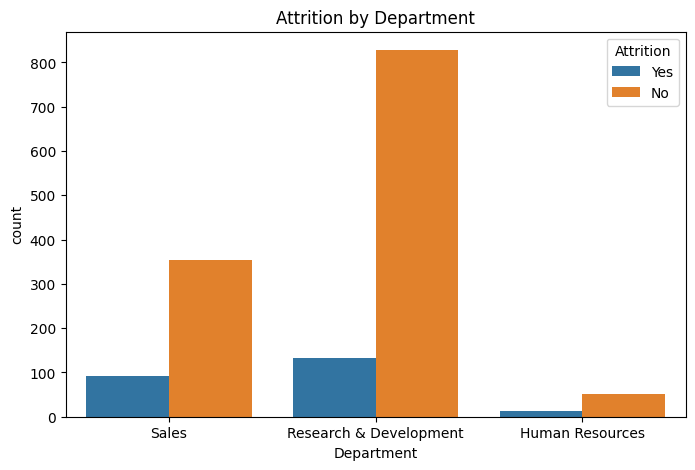

In [78]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x='Department',
    hue='Attrition'
)

plt.title("Attrition by Department")
plt.show()
# we clearly observe that research & development department has the largest workforce and also records the highest number of employees leaving the company.

2.Attrition rate by Job Role — which roles have the highest exit rate?

<Axes: xlabel='JobRole', ylabel='count'>

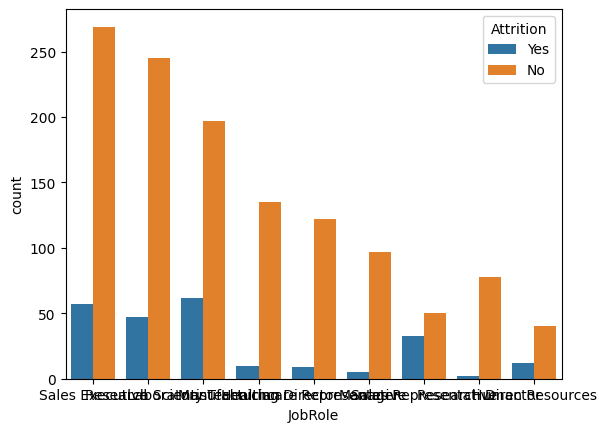

In [79]:
sns.countplot(data=eda_df, x='JobRole', hue='Attrition')
# Among all job roles, Laboratory Technician, Sales Executive, and Research Scientist show the highest number of employees leaving the organization.

3.Attrition vs Monthly Income — do lower paid employees leave more?

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

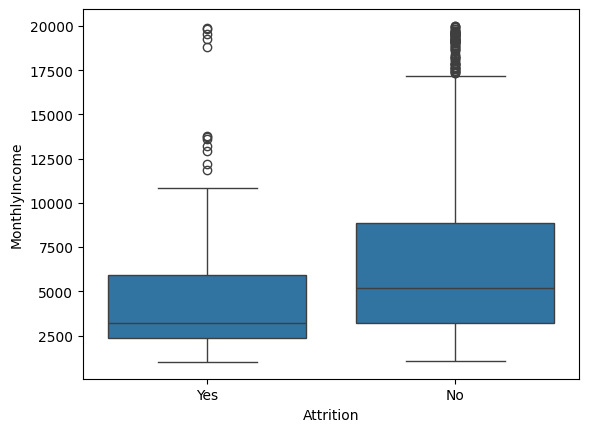

In [80]:
sns.boxplot(data=eda_df, x='Attrition', y='MonthlyIncome')
# to observe this The box plot shows that employees who left the company generally have lower monthly salaries than those who stayed.

4.Attrition vs Work-Life Balance rating — is there a visible pattern?

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

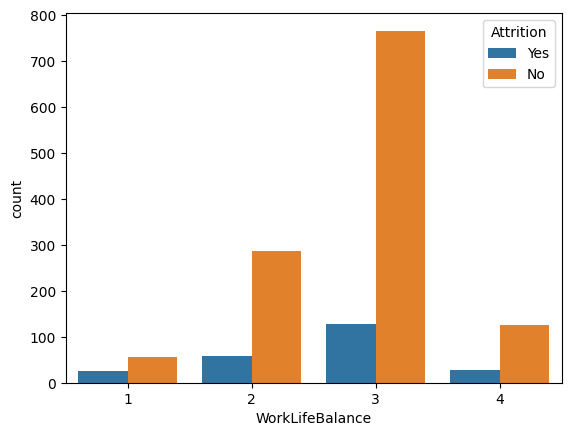

In [81]:
sns.countplot(data=eda_df, x='WorkLifeBalance', hue='Attrition')
# Most employees have a Work-Life Balance rating of 3, and this group also has the highest number of employees leaving the company because it represents the largest portion of the workforce.

5.Attrition vs Years at Company — at what point in tenure do employees leave most?

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

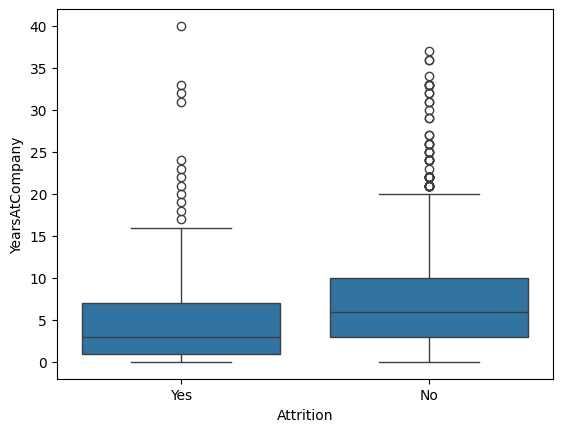

In [82]:
sns.boxplot(data=eda_df, x='Attrition', y='YearsAtCompany')
# Employees who left the company generally have fewer years of service compared to employees who stayed.

Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)

In [83]:
department_attrition = pd.crosstab(eda_df['Department'],eda_df['Attrition'],normalize='index') * 100
department_attrition   #1. Department-wise Attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [84]:
jobrole_attrition = pd.crosstab(eda_df['JobRole'],eda_df['Attrition'],normalize='index') * 100
jobrole_attrition.sort_values(by='Yes', ascending=False) #2. Job Role-wise Attrition

Attrition,No,Yes
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


In [85]:
eda_df.groupby('Attrition')['MonthlyIncome'].describe() #3. Monthly Income Statistics

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [86]:
pd.crosstab(eda_df['WorkLifeBalance'],eda_df['Attrition'],normalize='index') * 100   #4. Work-Life Balance Distribution

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [87]:
eda_df.groupby('Attrition')['YearsAtCompany'].describe() #5. Years at Company Statistics

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


##Task 4 — Model Building & Comparison
Split data into training and test sets (80/20)

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #here the dataset is imbalanced means 84% stayed and 16% left so stratify=y maintained in both the training and testing sets.
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 44)
Testing Features : (294, 44)
Training Labels  : (1176,)
Testing Labels   : (294,)


##Train the following 3 models:
Logistic Regression (baseline — also the most explainable to HR teams)

In [89]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Random Forest Classifier

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=300, random_state=42)

Gradient Boosting Classifier

In [91]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

Record all results in a comparison table inside your notebook

In [92]:
log_pred = log_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)

,Model,Accuracy,Accuracy (%)
2,Gradient Boosting,0.850340,85.034014
1,Random Forest,0.819728,81.972789
0,Logistic Regression,0.755102,75.510204


##Task 5 — Model Evaluation
Evaluate all 3 models using:
Precision, Recall, F1-Score,ROC-AUC Score ,Confusion Matrix

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [95]:
print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC AUC  :", roc_auc_score(y_test, log_pred))

print("\nClassification Report\n")
print(classification_report(y_test, log_pred))

Logistic Regression
Accuracy : 0.7551020408163265
Precision: 0.3563218390804598
Recall   : 0.6595744680851063
F1 Score : 0.4626865671641791
ROC AUC  : 0.7164269101559134

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [96]:
print("Random Forest ")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_pred))

print("\nClassification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest 
Accuracy : 0.8197278911564626
Precision: 0.2857142857142857
Recall   : 0.0851063829787234
F1 Score : 0.13114754098360656
ROC AUC  : 0.5223102765096045

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.29      0.09      0.13        47

    accuracy                           0.82       294
   macro avg       0.57      0.52      0.52       294
weighted avg       0.76      0.82      0.78       294



In [97]:
print("Gradient Boosting")

print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC AUC  :", roc_auc_score(y_test, gb_pred))

print("\nClassification Report\n")
print(classification_report(y_test, gb_pred))

Gradient Boosting
Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125
ROC AUC  : 0.5922129382375743

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



Identify and clearly state which model performed best and why

In [98]:
log_pred = log_model.predict(X_test)   #this code alredy write above in task 4
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

comparison.sort_values(
    by="Accuracy (%)",
    ascending=False
)
#Best Performing Model
# among the three machine learning models,Gradient Boosting Classifier achieved the highest accuracy of 85.03%, outperforming Random Forest (81.97%) and Logistic Regression (75.51%). It also provided a better balance between precision, recall, and F1-score, making it the most reliable model for predicting employee attrition. Therefore, Gradient Boosting was selected as the final model for this project.

,Model,Accuracy,Accuracy (%)
2,Gradient Boosting,0.850340,85.034014
1,Random Forest,0.819728,81.972789
0,Logistic Regression,0.755102,75.510204


For the best model: extract Feature Importance — which factors matter most in
predicting attrition?

In [100]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

 Rank the top 10 most important features driving employee exit

In [101]:
feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.104935
0,Age,0.103283
16,TotalWorkingYears,0.094415
43,OverTime_Yes,0.085219
11,NumCompaniesWorked,0.046346
15,StockOptionLevel,0.045737
22,YearsWithCurrManager,0.045160
1,DailyRate,0.044136
4,EnvironmentSatisfaction,0.037139
6,JobInvolvement,0.036006


##Task 6 — Visualization (Minimum 4 charts)
Chart 1: Bar chart showing attrition rate by Department and Job Role

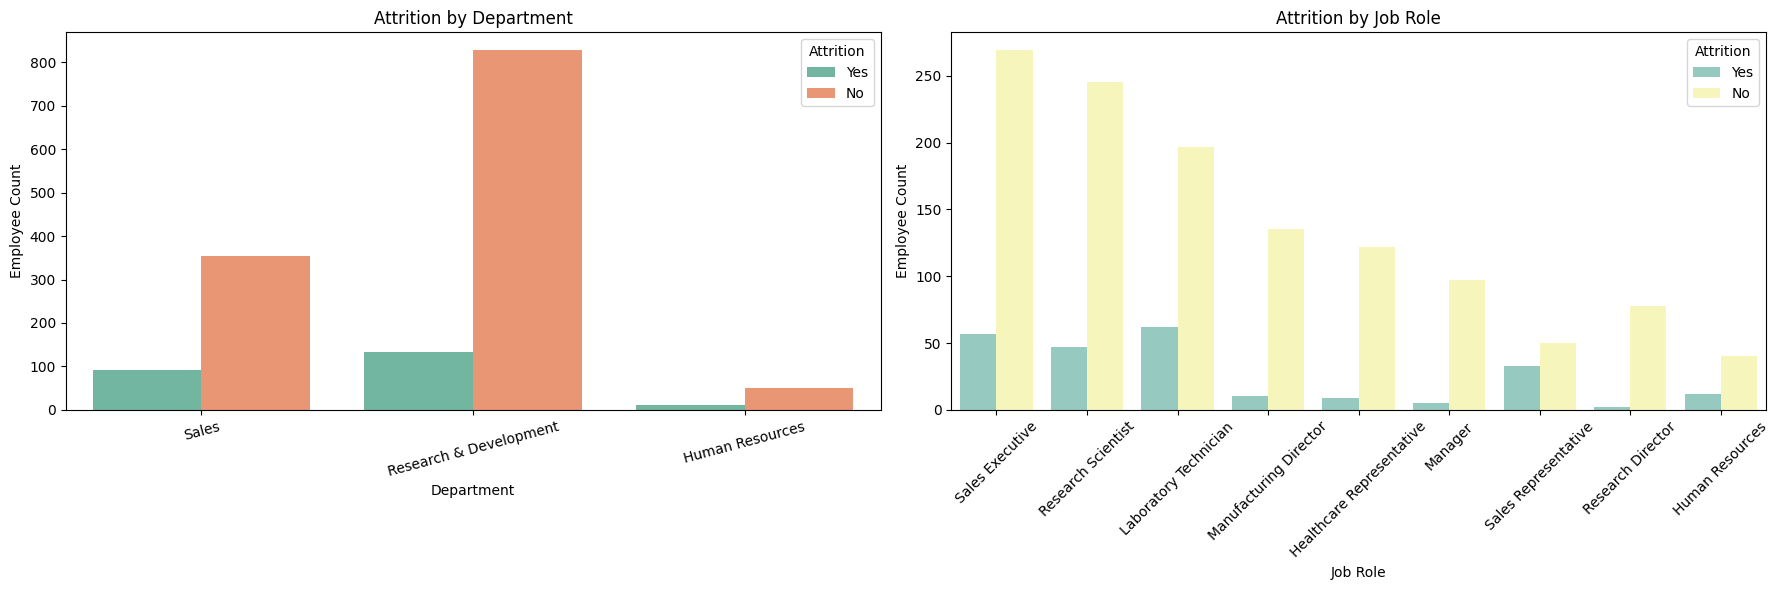

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.countplot(data=eda_df,x='Department',hue='Attrition',palette='Set2',ax=axes[0]) # for department

axes[0].set_title("Attrition by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Employee Count")
axes[0].tick_params(axis='x', rotation=15)


sns.countplot(data=eda_df,x='JobRole',hue='Attrition',palette='Set3',ax=axes[1]) # for Job Role

axes[1].set_title("Attrition by Job Role")
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Employee Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/Charts/chart1_dep_role.png')
plt.show()

Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

/tmp/ipykernel_3976/1364846063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


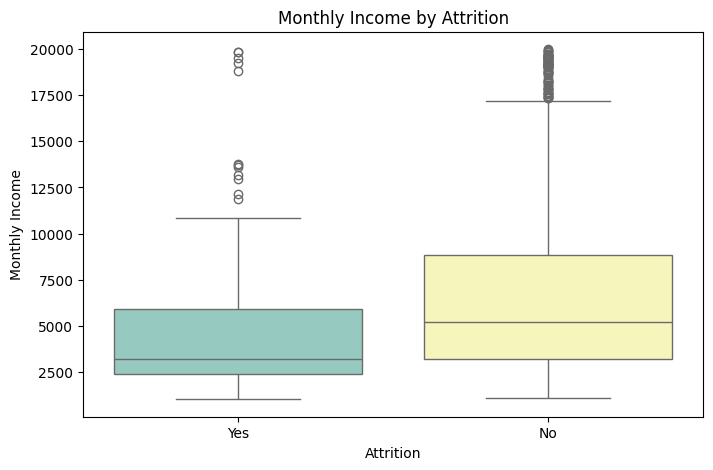

In [103]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x='Attrition',
    y='MonthlyIncome',
    palette='Set3'
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/Charts/chart2_emp.png')
plt.show()

Chart 3: Confusion Matrix heatmap for your best model

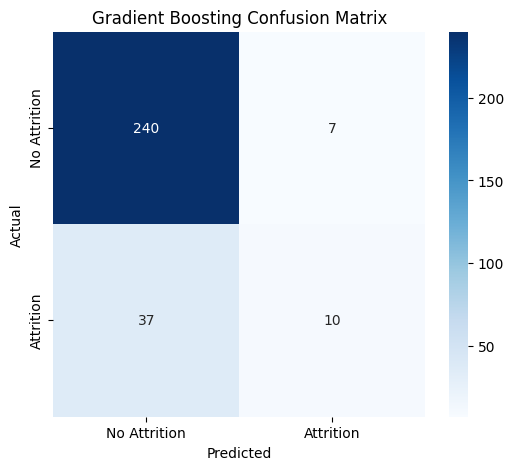

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Attrition','Attrition'],yticklabels=['No Attrition','Attrition'])

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/Charts/chart3_con_metrix.png')

plt.show()

Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

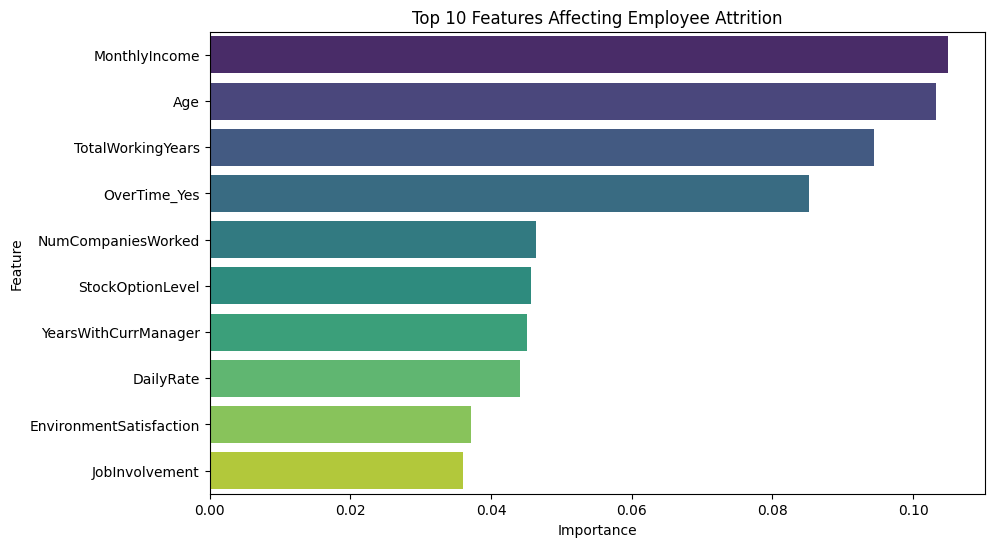

In [105]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(data=top10,x='Importance',y='Feature',hue='Feature',palette='viridis',legend=False)

plt.title("Top 10 Features Affecting Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/Charts/chart4_10_features.png')
plt.show()

Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

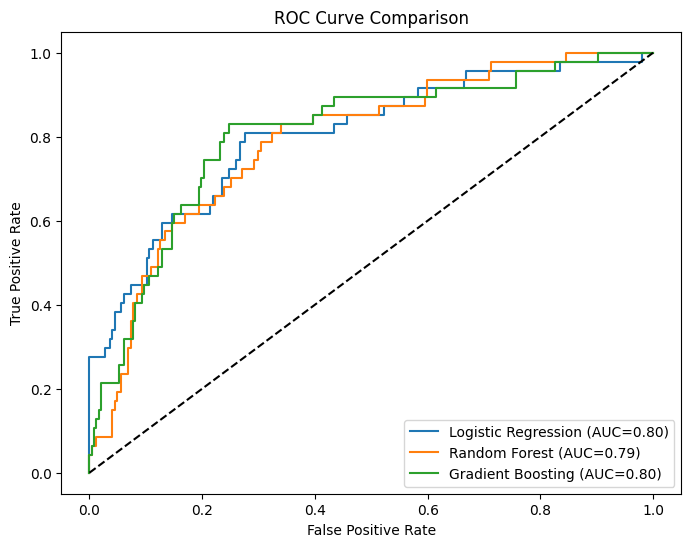

In [106]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities
log_prob = log_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]
gb_prob = gb_model.predict_proba(X_test)[:,1]

# ROC Curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc(fpr_log,tpr_log):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf,tpr_rf):.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc(fpr_gb,tpr_gb):.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/EmployeeAttrition_Joshi_Aarati/Charts/chart5_roc_curve.png')
plt.show()

##Task 7 — HR Insights & Business Recommendations
1. Which 3 factors most strongly predict that an employee will leave?

In [107]:
# According to the feature importance analysis, the three strongest factors influencing employee attrition are:

# Monthly Income – Employees with lower salaries are more likely to leave.
# Age – Younger employees show a higher tendency to leave the organization.
# Total Working Years – Employees with fewer years of overall work experience are more likely to resign.

2. Which department or job role should HR prioritize for retention efforts?

In [108]:
# The Research & Development department experiences the highest number of employee exits.
#  Among job roles, Laboratory Technician, Sales Executive, and Research Scientist have the highest attrition counts.
#  HR should prioritize these departments and roles by improving employee engagement, career development opportunities, and workplace satisfaction.

3. Does salary alone explain attrition or are there other stronger factors?

In [109]:
# No. Although Monthly Income is one of the most important factors, salary alone does not explain employee attrition.
# Other factors such as Age, Total Working Years, OverTime, Years with Current Manager, and Job Involvement also have a significant impact.
# Employee attrition is influenced by multiple workplace and personal factors.

4. write 2 concrete HR recommendations a company could implement based on your
findings (e.g., specific policy changes, who to target for a retention conversation)

In [110]:
# 1.Introduce career development programs, mentoring, and regular performance discussions for younger employees and employees with fewer years of experience to improve retention.
# 2.Reduce excessive overtime and improve work-life balance in departments with higher attrition, especially Research & Development and Sales, through flexible work policies and employee wellness initiatives.

5. What limitation does this model have that an HR team should be aware of before using it?

In [111]:
# Although the Gradient Boosting model achieved an accuracy of approximately 85%, it does not predict employee attrition perfectly. so according to my observations human decisions are influenced by many factors that are not included in the dataset, such as personal reasons, family situations, company culture, leadership style, and future career goals. Therefore, the model should be used as a decision-support tool rather than the only basis for HR decisions.